# Point Spread Function (PSF)

Response of a camera system to a point source (impulse)

## Gaussian PSF
$h(x,y) = \frac{1}{2\pi\sigma^2}\,e^{-\frac{x^2 + y^2}{2\sigma^2}}$





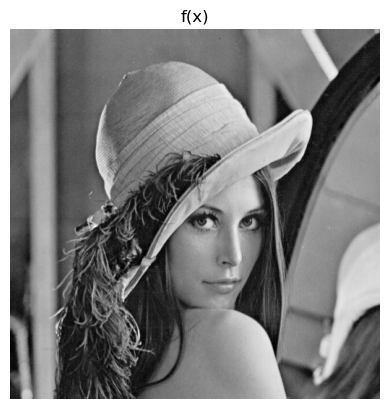

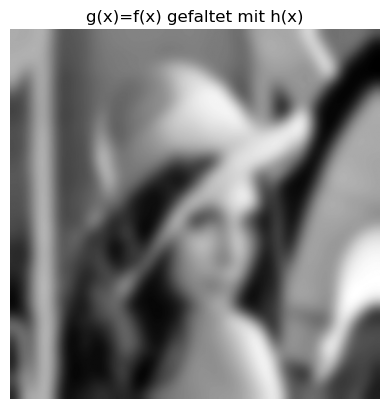

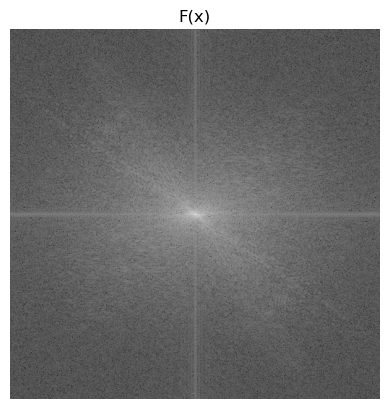

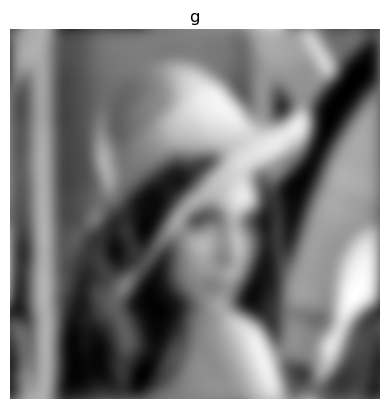

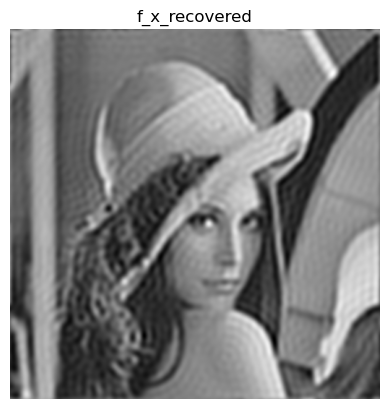

In [ ]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from DiscreteFourierTransform import myfft,myinvfft

def dispImg(img:np.ndarray,title:str = "dispImg:"):
        real_img = np.real(img)
        real_img = 255*(real_img/real_img.max())
        plt.imshow(real_img, cmap="gray")
        plt.title(title)
        plt.axis("off")
        plt.show()

def dispFreqDomainAmplitude(X_f:np.ndarray,title:str = "Magnitude F(u,v)"):
    X = X_f.copy()
    X = np.fft.ifftshift(X)
    X_mag = np.abs(X)
    X_mag = np.log1p(X_mag)
    X_mag = 255 * X_mag / np.max(X_mag)
    X_mag = X_mag.astype(np.uint8)
    plt.imshow(X_mag, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


def createGaussianPSF(sigma:int = 10,psf_size:tuple | None = None):

    if psf_size is None:
         psf_size = (int(3*sigma +1),int(3*sigma +1))

    h, w = psf_size

    x = np.arange(w) - w // 2   # Spalten
    y = np.arange(h) - h // 2   # Zeilen
    X, Y = np.meshgrid(x, y)

    pointSpreadGaus = 1/(2*np.pi*sigma**2) * np.exp(-(X**2 + Y**2)/(2*sigma**2))
    pointSpreadGaus /=pointSpreadGaus.sum()
    return pointSpreadGaus

f_x = cv2.imread("lena.bmp",cv2.IMREAD_UNCHANGED)
dispImg(f_x,"f(x)")

h_x_padded_zentriert = createGaussianPSF(sigma=10,psf_size=(f_x.shape[0],f_x.shape[1]))
blured_img = cv2.filter2D(f_x,-1,h_x_padded_zentriert)
dispImg(blured_img,"g(x)=f(x) gefaltet mit h(x)")

F = np.fft.fft2(f_x)
dispFreqDomainAmplitude(F,title="F(x)")
F_x,_,__ = myfft(f_x,verbose=False)
h_x_padded = np.fft.ifftshift(h_x_padded_zentriert)
H = np.fft.fft2(h_x_padded)
G = F*H
g = np.fft.ifft2(G)
dispImg(g,"g")

#  denoise mit Inversfilter
F_x_rec= np.zeros_like(G)
mask = np.abs(H) > 1e-6

F_x_rec[mask]= G[mask]/H[mask]
f_x_rec = np.fft.ifft2(F_x_rec)
dispImg(f_x_rec,"f_x_recovered")